# Exploratory Cohort Analysis & Retention Visualization
This notebook directly accesses the DuckDB instance built by our automated pipeline to visualize retention heatmaps and LTV curves.

In [1]:
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to the generated DuckDB data warehouse
con = duckdb.connect('../data/cohort_ltv.duckdb')

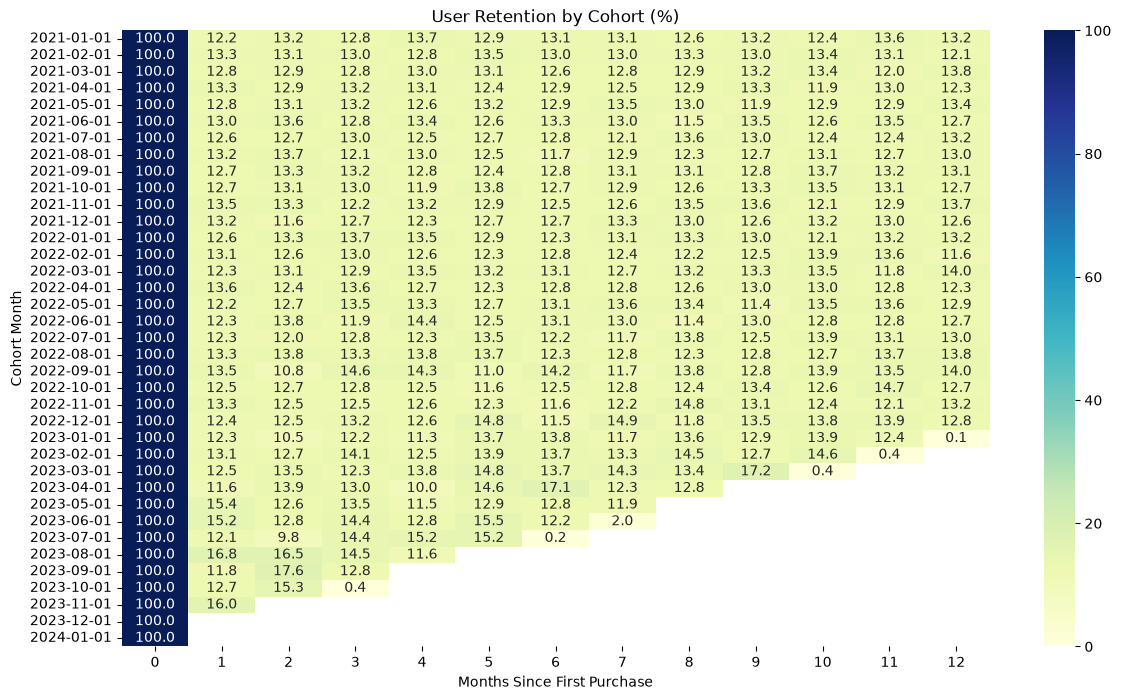

In [12]:
# Fetch Retention Matrix Data
df = con.execute("""
                 SELECT CAST(cohort_month AS VARCHAR) as cohort_month,
                        month_index,
                        retention_pct
                 FROM marts.cohort_retention
                 WHERE month_index <= 12
                 """).df()

# Pivot for Heatmap
retention_pivot = df.pivot(index='cohort_month', columns='month_index', values='retention_pct')

plt.figure(figsize=(14, 8))
sns.heatmap(retention_pivot, annot=True, fmt=".1f", cmap="YlGnBu", vmin=0.0, vmax=100.0)
plt.title('User Retention by Cohort (%)')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')
plt.show()

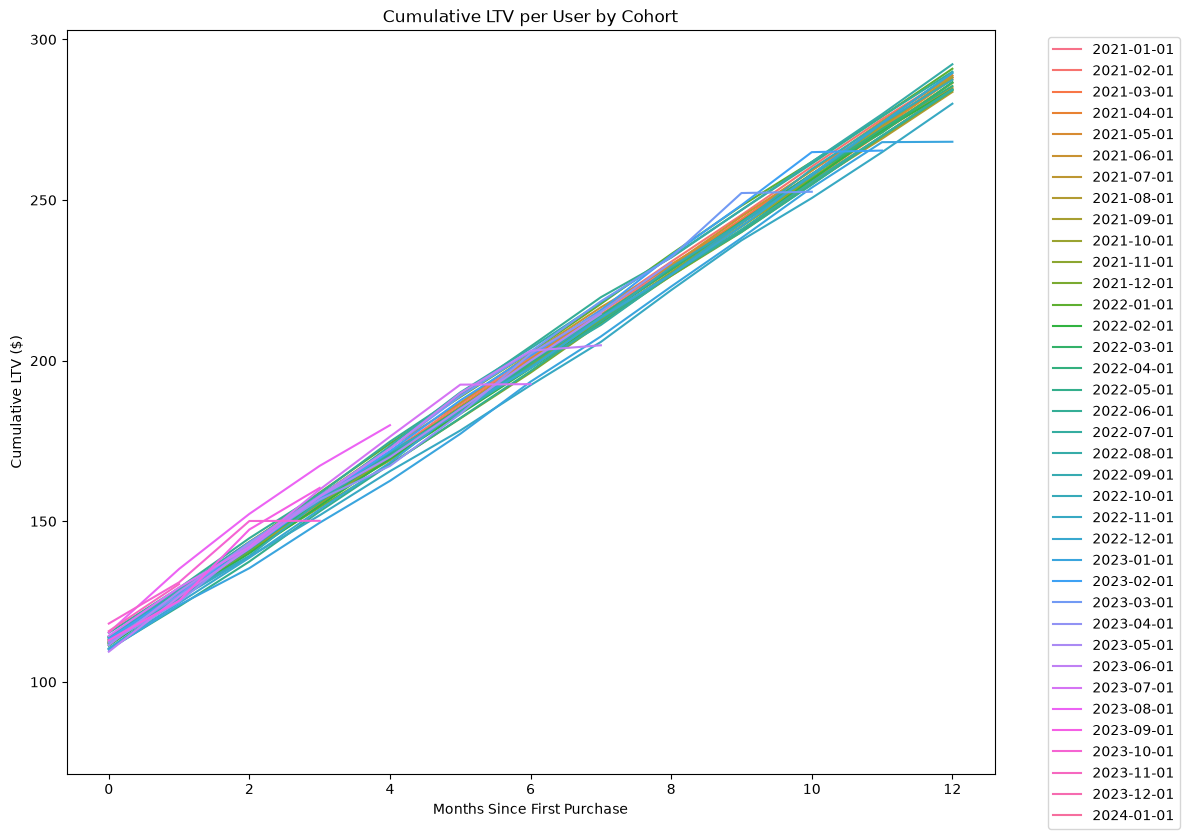

In [14]:
# Fetch LTV Curve Data
df_ltv = con.execute("""
                     SELECT CAST(cohort_month AS VARCHAR) as cohort_month,
                            month_index,
                            cumulative_ltv_per_user
                     FROM marts.cohort_retention
                     WHERE month_index <= 12
                     """).df()

plt.figure(figsize=(12, 9))
sns.lineplot(data=df_ltv, x='month_index', y='cumulative_ltv_per_user', hue='cohort_month')
plt.title('Cumulative LTV per User by Cohort')
plt.ylabel('Cumulative LTV ($)')
plt.xlabel('Months Since First Purchase')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()